# Billboard Top 100 Song Lyrics Data Analysis



This project explores trends in the Billboard Top 100 songs over the past ~65 years. The chosen dataset has columns for Album, Artist, Lyrics, Rank, Release Date, Writers, Title, and Year. This analysis will focus primarily on properties of song lyrics, such as word count and word repetition, over the years. 

In [175]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt

import statsmodels.api as sm

In [135]:
lyric_df = pd.read_csv('all_songs_data.csv')
lyric_df.columns

Index(['Album', 'Album URL', 'Artist', 'Featured Artists', 'Lyrics', 'Media',
       'Rank', 'Release Date', 'Song Title', 'Song URL', 'Writers', 'Year'],
      dtype='object')

## Data Cleaning and Derived Columns

First, we will construct a new dataframe with Release Date, Lyrics, Rank, and Writers. We will drop any NaN columns in the dataframe, and identify the range of years as an initial sanity check. 

In [136]:

lyric_df = lyric_df.dropna(axis=0, how='any').copy()
lyric_df['Year'] = lyric_df['Release Date'].astype(str).str[:4].astype(int)
lyric_df = lyric_df[lyric_df['Year'] >= 1960].reset_index(drop=True)
lyric_df.size
lyric_df.columns

Index(['Album', 'Album URL', 'Artist', 'Featured Artists', 'Lyrics', 'Media',
       'Rank', 'Release Date', 'Song Title', 'Song URL', 'Writers', 'Year'],
      dtype='object')

In [137]:
year_min = lyric_df['Year'].min()
year_max = lyric_df['Year'].max()
print(f"Year range: {year_min} to {year_max}")

Year range: 1960 to 2024


Next, we will derive columns for Word Count, Word Repetition, and Number of Writers. These new columns will help in later analysis. Word repetition is defined as the ratio of unique words to total words in the song, and should therefore take on a value between 0 and 1.

In [138]:
def calc_word_repitition(lyrics):
    lyrics_string = str(lyrics)
    word_set = set(lyrics_string.split(" "))
    uniuqe_words = len(word_set)
    total_words = len(lyrics_string.split())
    return uniuqe_words/total_words

def uniuqe_words(song):
    lyrics_string = str(song)
    word_set = set(lyrics_string.split(" "))
    return word_set

def calc_num_writers(writers):
    return len(str(writers).split(','))

In [139]:
df = lyric_df.copy()

df['Num_Writers'] = lyric_df['Writers'].apply(calc_num_writers)
df['Word_Count'] = df['Lyrics'].str.split().str.len()
df['Word_Repetition'] = df['Lyrics'].apply(calc_word_repitition)


As a sanity check, make sure the range of all derived columns makes sense.

In [140]:
print(f"Word Count range: {df['Word_Count'].min()} to {df['Word_Count'].max()}")
print(f"Word Repetition Rate range: {df['Word_Repetition'].min()} to {df['Word_Repetition'].max()}")
print(f"Number of Writers range: {df['Num_Writers'].min()} to {df['Num_Writers'].max()}")

Word Count range: 1 to 13661
Word Repetition Rate range: 0.09684684684684684 to 1.0
Number of Writers range: 1 to 251


It seems strange that songs would have a word repetition ratio of 1, as that would mean there is only one word in the song. I will extract a few examples of this, and see what's going on.

In [141]:
songs_rep_1 = df[df['Word_Repetition'] == 1]
songs_rep_1.head()

,Album,Album URL,Artist,Featured Artists,Lyrics,Media,Rank,Release Date,Song Title,Song URL,Writers,Year,Num_Writers,Word_Count,Word_Repetition
4,"Walk, Don’t Run",https://genius.com/albums/The-ventures/Walk-do...,Ventures,[],[Instrumental],"[{'provider': 'youtube', 'start': 0, 'type': '...",25,1960-12-05,"Walk, Dont Run",https://genius.com/The-ventures-walk-dont-run-...,"[{'api_path': '/artists/960589', 'header_image...",1960,8,1,1.0
443,They Only Come Out At Night,https://genius.com/albums/The-edgar-winter-gro...,Edgar Winter Group,[],[Instrumental],"[{'provider': 'youtube', 'start': 0, 'type': '...",16,1973-02-21,Frankenstein,https://genius.com/The-edgar-winter-group-fran...,"[{'api_path': '/artists/30304', 'header_image_...",1973,8,1,1.0
480,Rhapsody in White,https://genius.com/albums/The-love-unlimited-o...,Love Unlimited Orchestra,[],[Instrumental],"[{'provider': 'youtube', 'start': 0, 'type': '...",3,1973-11-09,Love's Theme,https://genius.com/The-love-unlimited-orchestr...,"[{'api_path': '/artists/3719', 'header_image_u...",1973,8,1,1.0
571,Saturday Night Fever: The Original Movie Sound...,https://genius.com/albums/Various-artists/Satu...,Walter Murphy and The Big Apple Band,"[{'api_path': '/artists/557048', 'header_image...",[Instrumental],"[{'provider': 'youtube', 'start': 0, 'type': '...",10,1976-05-29,A Fifth Of Beethoven,https://genius.com/Walter-murphy-a-fifth-of-be...,"[{'api_path': '/artists/32341', 'header_image_...",1976,16,1,1.0
1118,Beverly Hills Cop: Music From The Motion Pictu...,https://genius.com/albums/Various-artists/Beve...,Harold Faltermeyer,[],(instrumental),"[{'provider': 'youtube', 'start': 0, 'type': '...",61,1984-12-05,Axel F,https://genius.com/Harold-faltermeyer-axel-f-l...,"[{'api_path': '/artists/341899', 'header_image...",1984,8,1,1.0


There are many instrumental songs that just have "[instrumental]" in the lyrics column. I will remove any rows with only one word, and strip all lyrics of "[instrumental]" and "(instrumental)".

In [142]:

df['Lyrics'] = df['Lyrics'].astype(str).str.replace(r'\[instrumental\]|\(instrumental\)', '', regex=True, case=False)
df['Lyrics'] = df['Lyrics'].str.strip()  
df = df[df['Lyrics'].str.split().str.len() > 1].reset_index(drop=True)


13,661 words seems like a lot for a song. I will look at the exact song this is.

In [143]:
song_13661 = df[df['Word_Count'] == 13661]
print(song_13661['Lyrics'].iloc[0])


Last updated: 10/6/2018, 5:16PM MST OctoberOctober 6Jesse Powell — Jesse Powell (1996)October 5girl in red — chapter 1 (2018) Blanca — Shattered (2018) LouGotCash (feat. Trippie Redd) — "Too Turnt" (2018)October 4Terri Clark — Raising the Bar (2018) Jess Kent — "Girl" (2018) Joey Purp — QUARTERTHING (2018) Cypress Hill — "Crazy" (2018) Brooke Evers (feat. Rachel West & Glen Faria) — "Turn Around" (2018) Born Dirty (feat. jstlbby) — "Get Up Get Out" (2018) First Aid Kid — Tender Offerings (2018) Kap G — no kap (2018) Asiahn — "NOLA" (2018) Young Dolph — "By Mistake" (2018) Charlotte Lawrence — "Stole Your Car" (2018)October 3Howard — Together Alone (2018) Joji — "SLOW DANCING IN THE DARK" (2018) Joji — "YEAH RIGHT" (2018) Brett Young — "Here Tonight" (2018) Swizz Beatz (feat. Lil Wayne) — "Pistol on My Side (P.O.M.S)" (2018) Lil Baby & Gunna — "Drip Too Hard" (2018) Ciara — "Dose" (2018) Lana Del Rey — "Mariners Apartment Complex" (2018) Tori Kelly — Hiding Place (2018)October 2Noname —

This is clearly not the lyrics of a song. The longest song to ever reach the Top 100 Billboard is "Rap God" by Eminem, with 1,560 words. I will remove all rows with more than 1,560 words, to make sure no mistakes like this contaminate the data.

In [160]:

df = df[df['Word_Count'] <= 1560].reset_index(drop=True)


I will address any remaining data-cleaning issues if they come up in exploratory analysis.

## Exploratory Analysis

Next, I will make some bar charts plotting the relationships between Year, Word Count, and Word Repetition. I will try to visually identify any relationships that might be worth analyzing further.

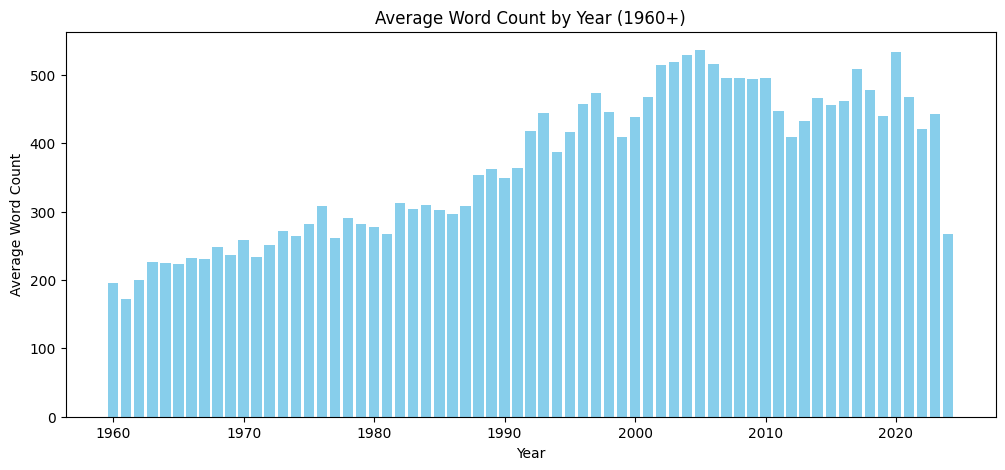

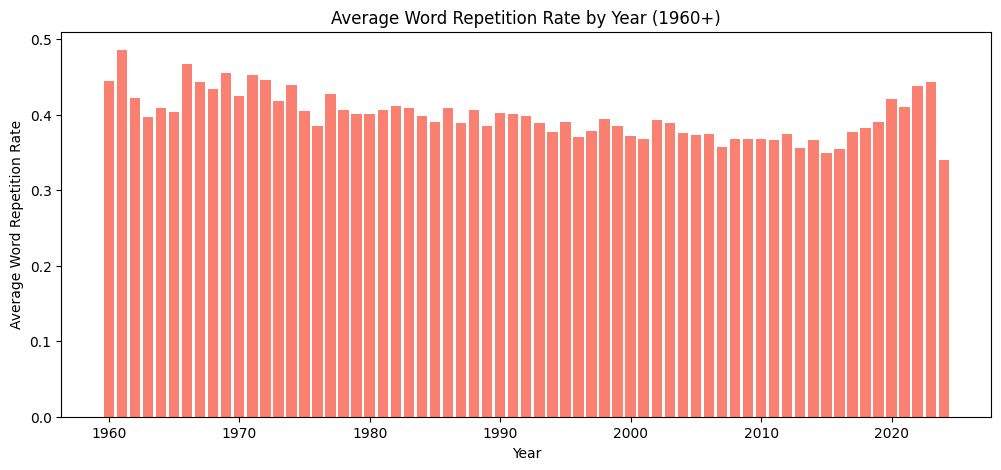

In [158]:


word_count_by_year = df.groupby('Year')['Word_Count'].mean().reset_index()
plt.figure(figsize=(12,5))
plt.bar(word_count_by_year['Year'], word_count_by_year['Word_Count'], color='skyblue')
plt.xlabel('Year')
plt.ylabel('Average Word Count')
plt.title('Average Word Count by Year (1960+)')
plt.show()

word_rep_by_year = df.groupby('Year')['Word_Repetition'].mean().reset_index()
plt.figure(figsize=(12,5))
plt.bar(word_rep_by_year['Year'], word_rep_by_year['Word_Repetition'], color='salmon')
plt.xlabel('Year')
plt.ylabel('Average Word Repetition Rate')
plt.title('Average Word Repetition Rate by Year (1960+)')
plt.show()

From these charts, I see a clear upward trend in average word count up until 2005, that flattens out after.

I also see a minor downward trend in word repetition from 1960 to 2010, with an upward trend from 2010-2023, though these relationships may not be strong enough to be significant.

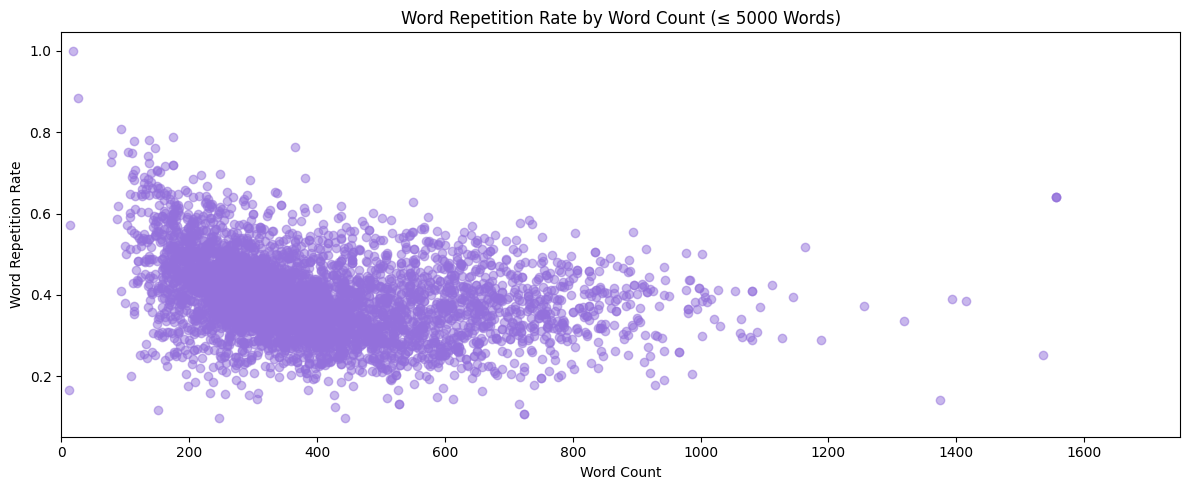

In [162]:

plt.figure(figsize=(12,5))
plt.scatter(df[df['Word_Count'] <= 5000]['Word_Count'], df[df['Word_Count'] <= 5000]['Word_Repetition'], alpha=0.5, color='mediumpurple')
plt.xlabel('Word Count')
plt.ylabel('Word Repetition Rate')
plt.title('Word Repetition Rate by Word Count (≤ 5000 Words)')
plt.xlim([0, 1750])
plt.tight_layout()
plt.show()

I see no clear relationship between word count and word repetition, though there may be a minor downward trend.

## Statistical Analysis and Interpretations

Based on the exploratory analysis, I've decided to fit 3 linear regression models, and perform hypothesis tests on the parameters to determine if the correlations are significant (p=0.05). 

Based on the limitations of both the dataset and my knowledge of music history, I will not be trying to make any causal claims about the relationships identified.

#### $$Model_1 :\text{Word Repetition} = \beta_0 + \beta_1 \cdot \text{Word Count} + \varepsilon$$

In [181]:
import statsmodels.api as sm

X = df['Word_Count']
y = df['Word_Repetition']
X_const = sm.add_constant(X)
model = sm.OLS(y, X_const).fit()

r_squared = model.rsquared
p_value = model.pvalues['Word_Count']
beta1 = model.params['Word_Count']

print(f"R^2: {r_squared}")
print(f"P-value for Word_Count: {p_value}")
print(f"Beta1 (slope): {beta1}")

R^2: 0.08086930235165235
P-value for Word_Count: 2.697306857926965e-83
Beta1 (slope): -0.0001460574359313533


Plot the Fitted Model

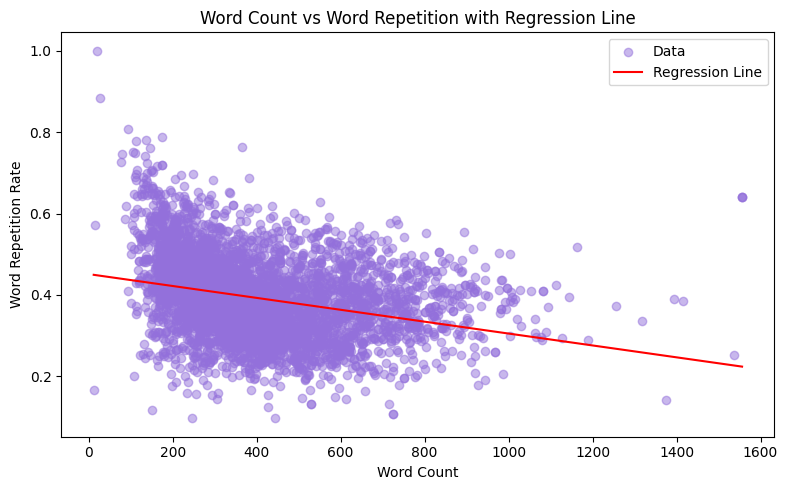

In [177]:
plt.figure(figsize=(8,5))
plt.scatter(df['Word_Count'], df['Word_Repetition'], alpha=0.5, label='Data', color='mediumpurple')

x_vals = np.linspace(df['Word_Count'].min(), df['Word_Count'].max(), 100)
y_pred = model.params['const'] + model.params['Word_Count'] * x_vals
plt.plot(x_vals, y_pred, color='red', label='Regression Line')

plt.xlabel('Word Count')
plt.ylabel('Word Repetition Rate')
plt.title('Word Count vs Word Repetition with Regression Line')
plt.legend()
plt.tight_layout()
plt.show()

A p-value of $2.67 \times 10^{-87}$ is strong evidence to reject the null hypothesis ($H_0: \beta_1 = 0$) that there is no relationship between word count and word repetition. However, a slope ($\hat{\beta}_1$) of $-0.000146$ and $R^2 = 0.08$ are low enough that the relationship is likely not meaningful in real life.

#### $$Model_2 :\text{Word Count} = \beta_0 + \beta_1 \cdot \text{Year} + \varepsilon$$

In [184]:
word_count_by_year = df.groupby('Year')['Word_Count'].mean().reset_index()
X2 = word_count_by_year['Year']
y2 = word_count_by_year['Word_Count']
X2_const = sm.add_constant(X2)
model2 = sm.OLS(y2, X2_const).fit()

r_squared2 = model2.rsquared
p_value2 = model2.pvalues['Year']
beta1_2 = model2.params['Year']

print(f"R^2: {r_squared2}")
print(f"P-value for Year: {p_value2}")
print(f"Beta1 (slope): {beta1_2}")


R^2: 0.7409833323893575
P-value for Year: 3.829650654068202e-20
Beta1 (slope): 4.887919949580112


Show fitted model on data:

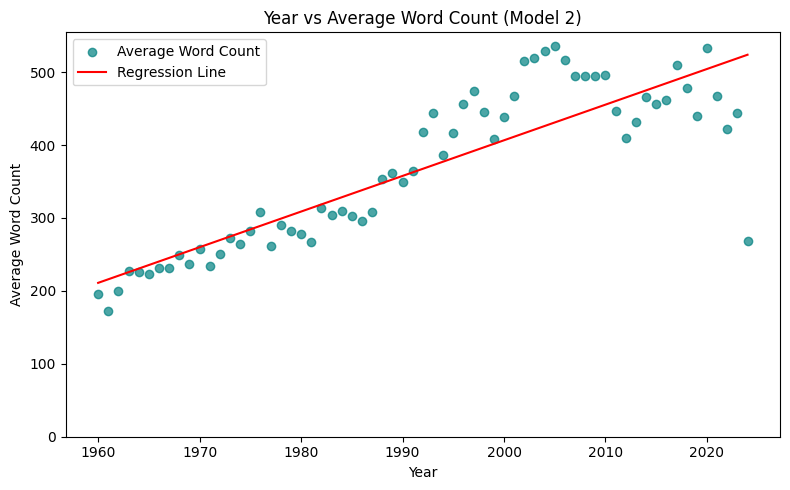

In [202]:
plt.figure(figsize=(8,5))
plt.scatter(X2, y2, alpha=0.7, label='Average Word Count', color='teal')
x_vals2 = np.linspace(X2.min(), X2.max(), 100)
y_pred2 = model2.params['const'] + model2.params['Year'] * x_vals2
plt.plot(x_vals2, y_pred2, color='red', label='Regression Line')
plt.xlabel('Year')
plt.ylabel('Average Word Count')
plt.title('Year vs Average Word Count (Model 2)')
plt.ylim(bottom=0)
plt.legend()
plt.tight_layout()
plt.show()

A p-value of $3.8 \times 10^{-20}$ is strong evidence to reject the null hypothesis ($H_0: \beta_1 = 0$) that there is no relationship between year and average word count. A slope ($\hat{\beta}_1$) of $4.888$ means that, on average, a one-year difference in the Billboard Top 100 is associated with a 4.888 word difference in average word count.

#### $$Model_3 :\text{Word Count} = \beta_0 + \beta_1 \cdot \text{Year (1960-2012)} + \varepsilon$$
#### $$Model_4 :\text{Word Count} = \beta_0 + \beta_1 \cdot \text{Year (2012-2023)} + \varepsilon$$

The plot below illustrates the data I will be fitting the two regression models on.

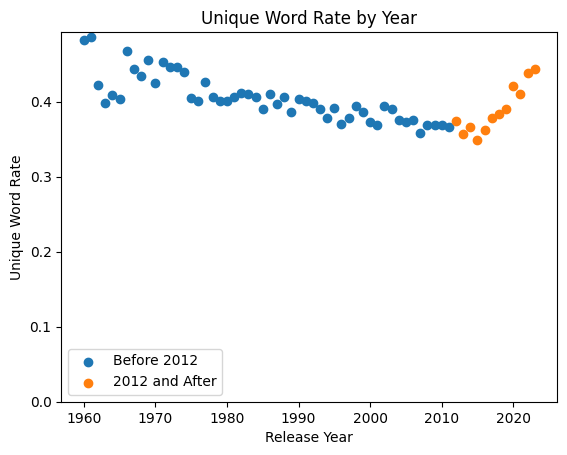

In [193]:

repitition_to_2012 = rep_by_year_cleaned[rep_by_year_cleaned['Release Date'] < 2012]
repitition_after_2012 = rep_by_year_cleaned[rep_by_year_cleaned['Release Date'] >= 2012]

plt.scatter(repitition_to_2012['Release Date'], repitition_to_2012['Unique_Word_Rate'], label='Before 2012')
plt.scatter(repitition_after_2012['Release Date'], repitition_after_2012['Unique_Word_Rate'], label='2012 and After')

plt.xlabel('Release Year')
plt.ylabel('Unique Word Rate')
plt.title('Unique Word Rate by Year')

plt.ylim(bottom=0)
plt.legend()
plt.show()

In [196]:
X3 = repitition_to_2012['Release Date']
y3 = repitition_to_2012['Unique_Word_Rate']
X3_const = sm.add_constant(X3)
model3 = sm.OLS(y3, X3_const).fit()
r_squared3 = model3.rsquared
p_value3 = model3.pvalues['Release Date']
beta1_3 = model3.params['Release Date']
print(f"Model 3 (1960-2012)")
print(f"R^2: {r_squared3}")
print(f"P-value for Year: {p_value3}")
print(f"Beta1 (slope): {beta1_3}")

X4 = repitition_after_2012['Release Date']
y4 = repitition_after_2012['Unique_Word_Rate']
X4_const = sm.add_constant(X4)
model4 = sm.OLS(y4, X4_const).fit()
r_squared4 = model4.rsquared
p_value4 = model4.pvalues['Release Date']
beta1_4 = model4.params['Release Date']
print(f"\nModel 4 (2012-2023)")
print(f"R^2: {r_squared4}")
print(f"P-value for Year: {p_value4}")
print(f"Beta1 (slope): {beta1_4}")

Model 3 (1960-2012)
R^2: 0.7008108536502111
P-value for Year: 1.053491634032528e-14
Beta1 (slope): -0.0016755214580339776

Model 4 (2012-2023)
R^2: 0.7976551365139877
P-value for Year: 9.158987102836934e-05
Beta1 (slope): 0.007874798915717407


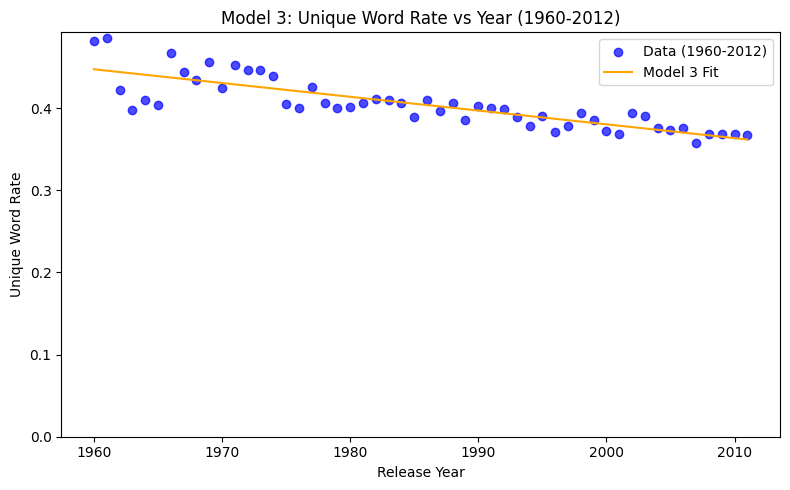

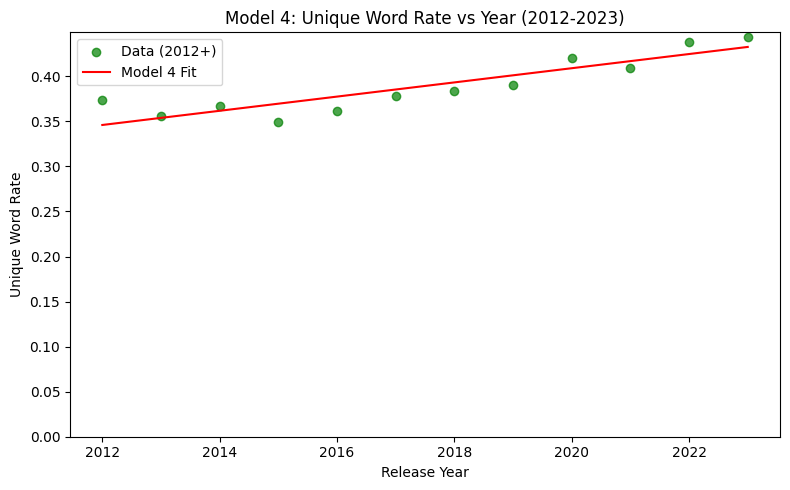

In [201]:
plt.figure(figsize=(8,5))
plt.scatter(X3, y3, alpha=0.7, label='Data (1960-2012)', color='blue')

x3_vals = np.linspace(X3.min(), X3.max(), 100)
y3_pred = model3.params['const'] + model3.params['Release Date'] * x3_vals

plt.plot(x3_vals, y3_pred, color='orange', label='Model 3 Fit')

plt.xlabel('Release Year')
plt.ylabel('Unique Word Rate')
plt.title('Model 3: Unique Word Rate vs Year (1960-2012)')
plt.ylim(bottom=0)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(X4, y4, alpha=0.7, label='Data (2012+)', color='green')

x4_vals = np.linspace(X4.min(), X4.max(), 100)
y4_pred = model4.params['const'] + model4.params['Release Date'] * x4_vals

plt.plot(x4_vals, y4_pred, color='red', label='Model 4 Fit')
plt.xlabel('Release Year')
plt.ylabel('Unique Word Rate')
plt.title('Model 4: Unique Word Rate vs Year (2012-2023)')
plt.ylim(bottom=0)
plt.legend()
plt.tight_layout()
plt.show()

p-values of $1.05 \times 10^{-14}$ and $9.16 \times 10^{-5}$ give evidence to reject the null hypotheses that there is no linear association between release year and unique word rate for the intervals from 1960-2012, and 2012-2023.

The slope from 1960 to 2012 is $-0.0017$, meaning that, on average, the ratio of unique words to total words decreases by 0.0017 for every 1 year difference in the Billboard Top 100 songs.

The slope from 2012 to 2023 is $0.0079$, meaning that, on average, the ratio of unique words to total words increases by 0.0079 for every 1 year difference in the Billboard Top 100 songs.

## Conclusion

Based on this analysis, I believe that there is strong evidence to suggest both average word repetition and average word count in the lyrics of Billboard Top 100 songs have changed over the years.

The strongest relationship I found was with year and word count. Since 1960, the average word count of songs has seemed to increase consistently. The relationship between word repetition and year is weaker, but still significant.

## Limitations and Next Steps

There are many things I could improve for this analysis. The first is to be more thorough with the initial data cleaning. I took steps to make sure all of the data seemed reasonable, but there are very likely still errors in some of the lyrics columns.

Additionally, I did not assess any of the assumptions for Linear Regression. To strengthen my interpretation of the results, I should make sure the Normality, Linearity, and Equal Variance assumptions are not significantly violated.